In [21]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [22]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [23]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [24]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(100)
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [25]:
flarelist

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,2024-05-20 05:14:40.351,15995187,409599,884735,475135,204799,247.0,37.0,...,2405200514,0.750127,X6,X25,X12,5.834281e-04,0.002534,0.001198,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024052...
15798,2024-05-14T16:43:32.086,2024-05-14T17:02:16.088,2024-05-14 16:47:32.086,13148990,442367,753663,311295,155647,303.0,41.0,...,2405141647,0.754086,X4,X18,X8,4.217016e-04,0.001782,0.000854,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
4360,2022-09-29T11:44:36.211,2022-09-29T12:51:48.218,2022-09-29 11:51:36.211,6411371,376831,507903,188415,77823,271.0,45.0,...,2209291151,0.798857,M7,X3,X1,7.000000e-05,0.000300,0.000100,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022092...
4361,2022-09-29T11:44:32.211,2022-09-29T12:51:56.218,2022-09-29 11:57:32.212,1769471,376831,507903,188415,77823,271.0,45.0,...,2209291157,0.800781,M2,M8,M4,2.000000e-05,0.000080,0.000040,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022092...
21278,2024-10-03T12:04:29.984,2024-10-03T13:15:41.992,2024-10-03 12:12:37.985,27216076,376831,622591,139263,34815,303.0,41.0,...,2410031212,0.878912,X1,X6,X3,1.490822e-04,0.000575,0.000289,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024100...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12385,2024-02-02T12:57:47.995,2024-02-02T13:58:08.001,2024-02-02 13:26:11.998,2148207,311295,69631,13823,3455,231.0,37.0,...,2402021326,0.757078,X1,X4,X2,1.057454e-04,0.000395,0.000201,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024020...
1349,2022-03-30T17:18:15.999,2022-03-30T18:46:12.008,2022-03-30 17:30:16.000,6478852,221183,59391,12799,1855,303.0,49.0,...,2203301730,0.793860,M5,X2,M9,5.000000e-05,0.000200,0.000090,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022033...
28196,2025-08-22T03:58:53.389,2025-08-22T04:04:53.390,2025-08-22 04:01:09.389,5509,3199,4863,12799,29695,303.0,41.0,...,2508220401,NaN,B8,C2,C1,8.214886e-07,0.000002,0.000001,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2025082...
28194,2025-08-22T03:45:29.388,2025-08-22T03:49:13.388,2025-08-22 03:46:05.388,5509,2175,4351,12799,29695,303.0,41.0,...,2508220346,NaN,B8,C2,C1,8.216693e-07,0.000002,0.000001,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2025082...


In [26]:
# df_list=[]
# indices=[]
# for ind in flarelist.index:
#     sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
#                                    flarelist['end_UTC'].loc[ind]), 
#                         a.Instrument.stix,
#                         a.stix.DataType.sci,
#                         a.stix.DataProduct.sci_xray_spec)
#     sci_query['stix'].filter_for_latest_version()
    
#     start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
#     end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

#     overlaps_ranked = rank_overlaps(start, end, sci_query)
    
#     for index in overlaps_ranked[:,1]:
#         # badrange=False
#         sci_files = Fido.fetch(sci_query[0][int(index)])
#         sci_data = Product(sci_files)
    
#         # if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
#         #     badrange=True
        
#         # if not badrange:
#             sci_df = get_stix_df(sci_data, energy_ranges)
#             df_list.append(sci_df)
#             indices.append(ind)
#             break
    
#     # df = combined_df[~combined_df.index.duplicated(keep="first")]

#     # df_list[ind]=df

#     # sci_df = get_stix_df(sci_data, energy_ranges)
#     # df_list.append(sci_df)
#     # indices.append(ind)

In [27]:
# df_list=[]
# indices=[]
# testlengths=[]
# for ind in top100.index:
#     sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
#                                    top100['end_UTC'].loc[ind]), 
#                         a.Instrument.stix,
#                         a.stix.DataType.sci,
#                         a.stix.DataProduct.sci_xray_spec)
#     sci_query['stix'].filter_for_latest_version()
#     testlengths.append(len(sci_query[0]))
    
#     start = parse_time(top100['start_UTC'].loc[ind]).datetime
#     end = parse_time(top100['end_UTC'].loc[ind]).datetime

#     overlaps_ranked = rank_overlaps(start, end, sci_query)
    
#     for index in overlaps_ranked[:,1]:
#         badrange=False
#         sci_files = Fido.fetch(sci_query[0][int(index)])
#         sci_data = Product(sci_files)
    
#         if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
#             badrange=True
        
#         if not badrange:
#             sci_df = get_stix_df(sci_data, energy_ranges)
#             df_list.append(sci_df)
#             indices.append(ind)
#             break

In [28]:
df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1
    
    #  first_start = min(sci_query[0][n][0].datetime for n in range(len(sci_query[0])))   
    # for file in sci_query[0]:
    #     if file[0].datetime==first_start:
    #         if file[1].datetime>=t(flarelist['end_UTC'].loc[ind]):
    #             sci_files = Fido.fetch(sci_query[0][int(overlaps_ranked[0][1])])
    #             sci_data = Product(sci_files)
            
    #             sci_df = get_stix_df(sci_data, energy_ranges)
    #             df_list.append(sci_df)
    #             indices.append(ind)
    #             break
    #         else:
    #             no_file.append(i)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [29]:
range(len(sci_query[0]))

range(0, 1)

In [30]:
len(df_list)

100

In [31]:
no_file

[9, 10, 26, 31, 74, 90]

In [32]:
print(flarelist['start_UTC'].iloc[9], flarelist['end_UTC'].iloc[9])

2024-05-15T20:22:27.966 2024-05-15T21:35:47.874


In [33]:
sci_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[9], 
                                   flarelist['end_UTC'].iloc[9]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-15T14:29:59.000,2024-05-15T20:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405155111
2024-05-15T20:29:58.000,2024-05-16T02:35:05.000,STIX,L1,SCI,sci-xray-spec,V04,2405157409


In [34]:
print(flarelist['start_UTC'].iloc[10], flarelist['end_UTC'].iloc[10])

2024-05-15T08:10:19.989 2024-05-15T09:30:39.996


In [35]:
sci_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[10], 
                                   flarelist['end_UTC'].iloc[10]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-15T02:29:58.000,2024-05-15T08:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405153125
2024-05-15T08:29:59.000,2024-05-15T14:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405156793


In [36]:
first_start = min(sci_query[0][n][0].datetime for n in range(len(sci_query[0])))
first_start

datetime.datetime(2024, 5, 15, 2, 29, 58)

In [37]:
# df=df_list[10]

# fig, ax = plt.subplots()
# ax.set_ylabel('ct/(keV s)')
# ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[10]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[10]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[10]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[10]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[10]).datetime.minute}")
# ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

# ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
# ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

# plt.axvline(t(flarelist['start_UTC'].iloc[10]), 0, 1, linestyle='dashed', color='yellow')
# plt.axvline(t(flarelist['end_UTC'].iloc[10]), 0, 1, linestyle='dashed', color='yellow')
# plt.axvline(t('2024-05-15T08:34:59.000'), 0, 1, linestyle='dotted', color='red')   

In [38]:
print(flarelist['start_UTC'].iloc[26],flarelist['end_UTC'].iloc[26])

2024-05-14T02:01:28.090 2024-05-14T03:03:52.097


In [39]:
sci_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[26], 
                                   flarelist['end_UTC'].iloc[26]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-13T20:30:02.000,2024-05-14T02:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405131256
2024-05-14T02:29:58.000,2024-05-14T08:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405141390


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

<Axes: ylabel='ct/(keV s)'>

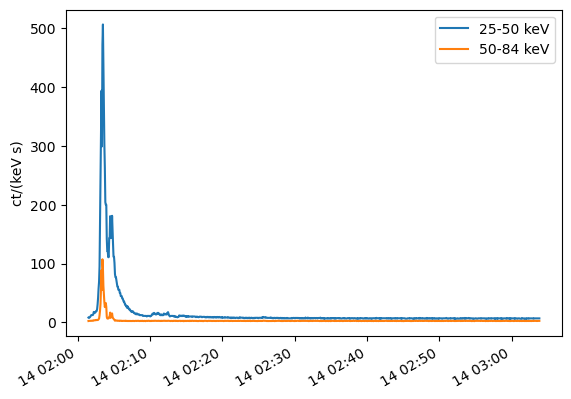

In [40]:
stix_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[26],flarelist['end_UTC'].iloc[26]), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

stix_files = Fido.fetch(stix_query)
stix_lc = ts.TimeSeries(stix_files, concatenate=True)
stix_df = stix_lc.to_dataframe()

stix_df.index = parse_time(stix_df.index).datetime
stix_df = stix_df.truncate(t(flarelist['start_UTC'].iloc[26]),t(flarelist['end_UTC'].iloc[26]))

#plotting lightcurves
fig, ax = plt.subplots()
ax.set_yscale('linear')
ax.set_ylabel('ct/(keV s)')
# stix_df.plot(ax=ax, y='4-10 keV')
# stix_df.plot(ax=ax, y='10-15 keV')
# stix_df.plot(ax=ax, y='15-25 keV')
stix_df.plot(ax=ax, y='25-50 keV')
stix_df.plot(ax=ax, y='50-84 keV')

In [41]:
print(flarelist['start_UTC'].iloc[90], flarelist['end_UTC'].iloc[90])

2023-09-11T22:13:20.137 2023-09-11T23:36:00.146


In [42]:
sci_query = Fido.search(a.Time(flarelist['start_UTC'].iloc[90], 
                                  flarelist['end_UTC'].iloc[90]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-09-11T16:30:00.000,2023-09-11T22:35:00.000,STIX,L1,SCI,sci-xray-spec,V04,2309118146
2023-09-11T22:30:00.000,2023-09-12T04:35:01.000,STIX,L1,SCI,sci-xray-spec,V04,2309112494


In [43]:
len(df_list)

100

AttributeError: 'float' object has no attribute 'index'

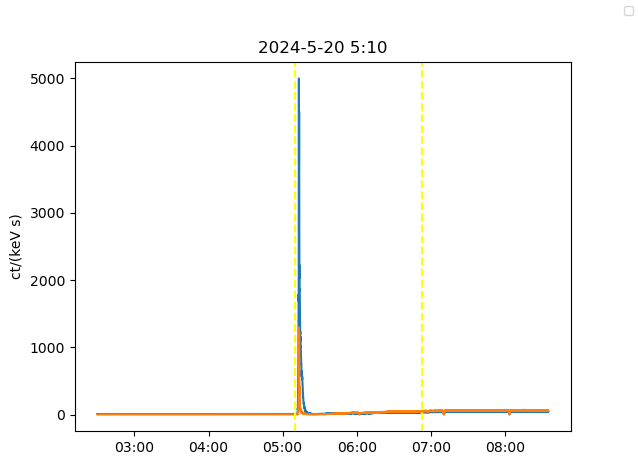

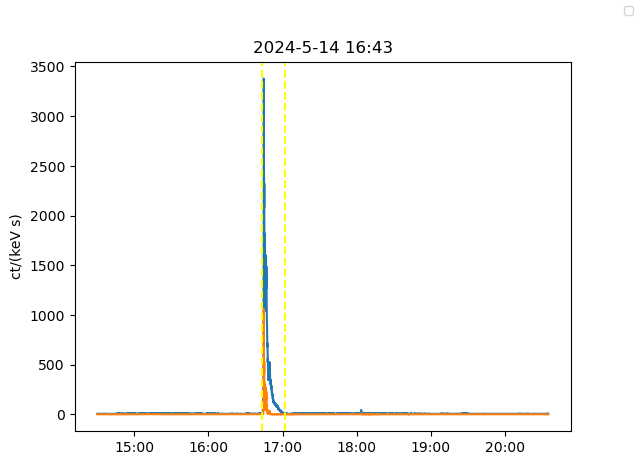

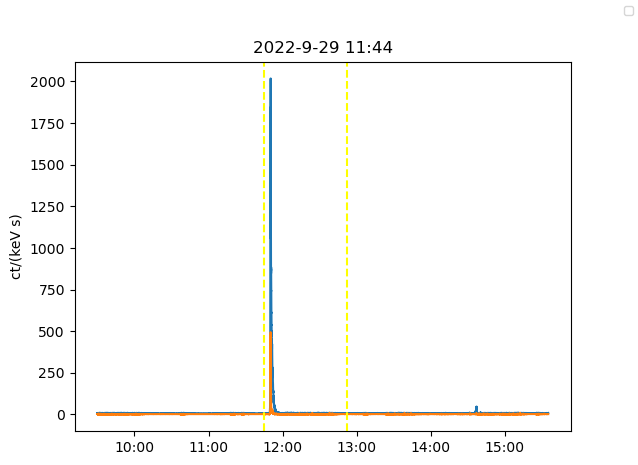

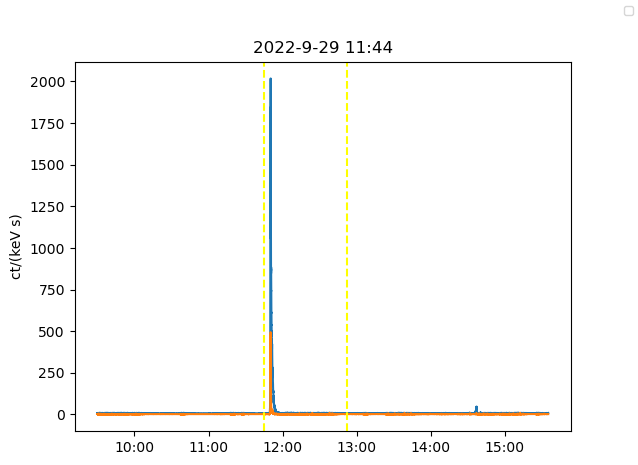

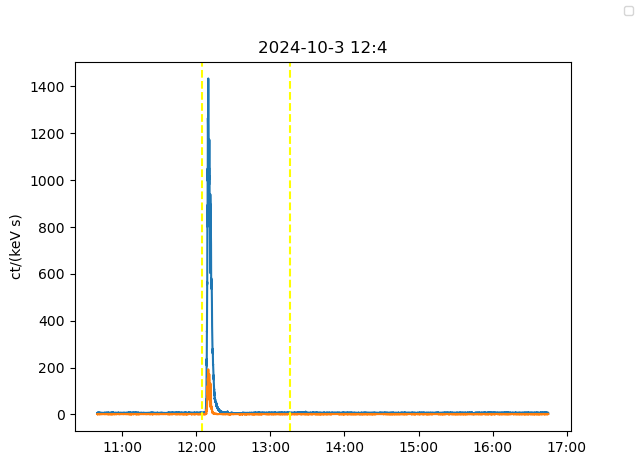

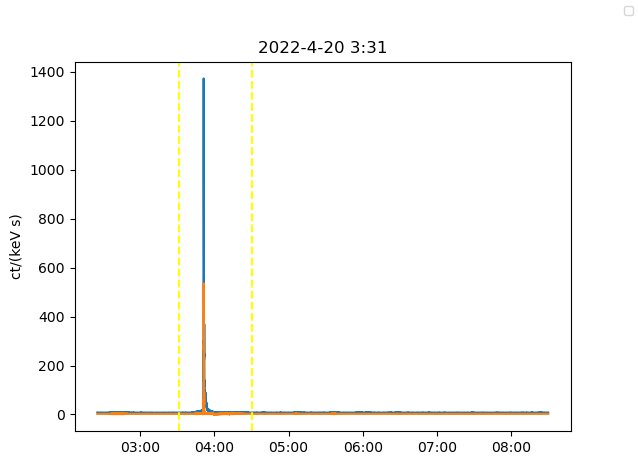

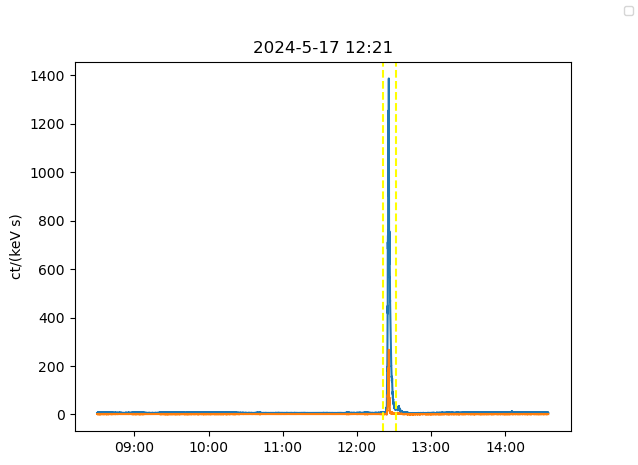

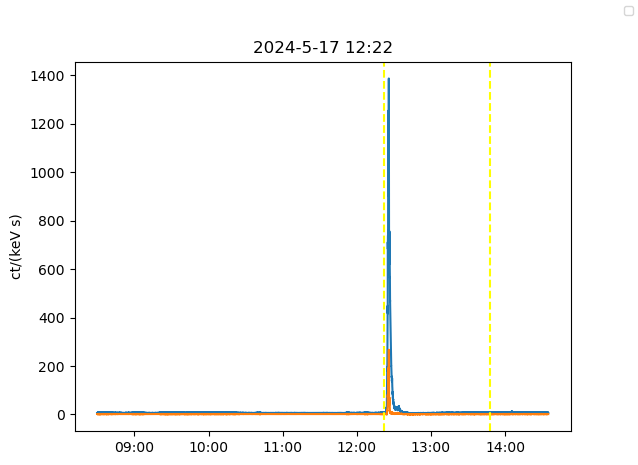

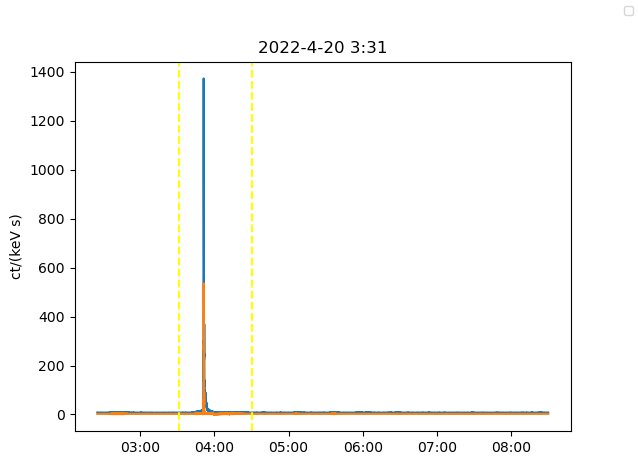

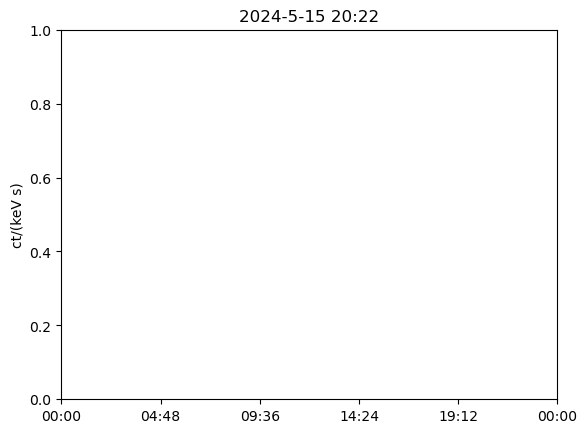

In [44]:
i=0
for df in df_list:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
    ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
    ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

    plt.axvline(t(flarelist['start_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
    plt.axvline(t(flarelist['end_UTC'].iloc[i]), 0, 1, linestyle='dashed', color='yellow')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/test1/flare"+str(i)+".png", bbox_inches='tight')
    
    i+=1

plt.close('all')

In [45]:
flarelist['end_UTC'].iloc[99]

'2024-06-10T11:36:04.293'

In [93]:
flag1=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        df = df.truncate(t(flarelist['start_UTC'].iloc[iloc])+dt.timedelta(minutes=30), t(flarelist['end_UTC'].iloc[iloc])+dt.timedelta(minutes=30))
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag1.append(True)
            bigger=True
        if not bigger:
            flag1.append(False)
    else:
        flag1.append(True)
    iloc+=1

In [96]:
flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [97]:
checklist2 = list(np.where(np.array(flag2)==True)[0])
checklist2

[np.int64(0),
 np.int64(9),
 np.int64(10),
 np.int64(14),
 np.int64(16),
 np.int64(26),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(35),
 np.int64(37),
 np.int64(38),
 np.int64(44),
 np.int64(48),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(74),
 np.int64(78),
 np.int64(79),
 np.int64(81),
 np.int64(83),
 np.int64(84),
 np.int64(86),
 np.int64(87),
 np.int64(88),
 np.int64(90),
 np.int64(93),
 np.int64(94),
 np.int64(97),
 np.int64(98)]

In [47]:
checklist = list(np.where(np.array(flag1)==True)[0])
checklist

[np.int64(0),
 np.int64(9),
 np.int64(10),
 np.int64(14),
 np.int64(26),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(38),
 np.int64(40),
 np.int64(48),
 np.int64(54),
 np.int64(59),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(69),
 np.int64(70),
 np.int64(72),
 np.int64(74),
 np.int64(78),
 np.int64(79),
 np.int64(83),
 np.int64(86),
 np.int64(87),
 np.int64(88),
 np.int64(90),
 np.int64(93),
 np.int64(94),
 np.int64(97),
 np.int64(98)]

In [48]:
flag=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        df = df.truncate(flarelist['start_UTC'].iloc[iloc], flarelist['end_UTC'].iloc[iloc])
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                flag.append(True)
                bigger=True
                break
        if not bigger:
            flag.append(False)
    iloc+=1

AttributeError: 'float' object has no attribute 'truncate'

In [49]:
len(flag)

9

In [50]:
np.where(np.array(flag)==True)

(array([0, 2, 3]),)

In [206]:
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=15)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=15)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.05) & (flare_df.index<flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_start = start_df.index[0]
        end_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>-0.05) & (flare_df.index>flare_df.index[flare_df['25.0 keV-50.0 keV'] == np.max(flare_df['25.0 keV-50.0 keV'])][0])]
        diff_estimated_end = end_df.index[-1]
    
        estimated_starts.append(diff_estimated_start)
        estimated_ends.append(diff_estimated_end)
    
        estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()
        durations.append(estimated_duration)
    
        flare_df_50100 = flare_df[np.abs(flare_df['50.0 keV-100.0 keV'].diff())>0.02]

        if not flare_df_50100.empty:
            diff_estimated_start_50100 = flare_df_50100.index[0]
            diff_estimated_end_50100 = flare_df_50100.index[-1]
    
            estimated_starts_50100.append(diff_estimated_start_50100)
            estimated_ends_50100.append(diff_estimated_end_50100)
    
            estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
            durations_50100.append(estimated_duration_50100)
    
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [147]:
no_file

[9, 10, 26, 31, 74, 90]

In [148]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

In [154]:
df_list_extrafiltered = []
for df in df_list_refined:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 75, polyorder=3)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 75, polyorder=3)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [155]:
range_x=np.arange(0, 100, 1)
locs=list(set(range_x)-set(checklist2))
len(locs)

56

In [207]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [205]:
i=0
track=0
for i in range(len(df_list)):
    if i not in checklist2:
        df = df_list_extrafiltered[track]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
        start = t(times_25_50[0][track])
        end = t(times_25_50[1][track])
        
        df = df.truncate(start - dt.timedelta(minutes=30), end + dt.timedelta(minutes=30))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(start, 0, 1, linestyle='dashed', color='palevioletred')
        plt.axvline(end, 0, 1, linestyle='dashed', color='palevioletred')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/2550_counts_durations_filtered/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_11852\2080398999.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [208]:
i=0
track=0
for i in range(len(df_list)):
    if i not in checklist2:
        df = df_list_refined[track]
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
        start = t(times_25_50[0][track])
        end = t(times_25_50[1][track])
        
        df = df.truncate(start - dt.timedelta(minutes=30), end + dt.timedelta(minutes=30))
        
        ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
        ax.plot(t(df.index), df['50.0 keV-100.0 keV'])
    
        plt.axvline(start, 0, 1, linestyle='dashed', color='palevioletred')
        plt.axvline(end, 0, 1, linestyle='dashed', color='palevioletred')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/2550_counts_durations/flare"+str(i)+".png", bbox_inches='tight')
        track+=1

plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_11852\2093946754.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [177]:
starts=times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

In [178]:
max(durations)

7379.9

In [184]:
resampled_df_list = []
i=0
for df in df_list_refined:
    df_x = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df_x.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [170]:
test = df_list_refined[13].truncate(starts[13], starts[13]+dt.timedelta(seconds=2377))
test

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-10-31 20:58:11.714,6.036000,1.666000
2024-10-31 20:58:31.464,6.178462,1.610256
2024-10-31 20:58:50.664,6.336508,1.614815
2024-10-31 20:59:01.614,6.226667,1.946667
2024-10-31 20:59:13.014,6.149495,1.715152
...,...,...
2024-10-31 21:37:36.114,5.413333,1.433333
2024-10-31 21:37:39.114,6.000000,1.486667
2024-10-31 21:37:42.114,5.586667,1.406667
2024-10-31 21:37:45.114,5.226667,1.406667


In [172]:
resampled_df = test.resample('1s').mean()
resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')

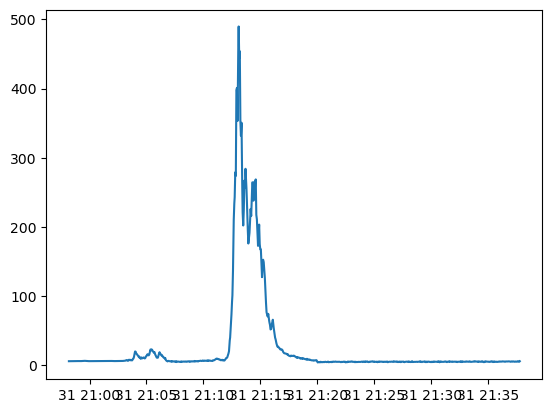

In [173]:
plt.plot(resampled_df.index, resampled_df['25.0 keV-50.0 keV'])

In [181]:
i=0
for df in resampled_df_list:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    df.index = parse_time(df.index).datetime

    for n in range(len(df.columns)):
        ax.plot(df.index, df[df.columns[n]], label=df.columns[n])
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/resampling/flare"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_11852\1795214086.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [182]:
normalised_df_list = []
for df in resampled_df_list:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list.append(normalised_df)

In [185]:
timeshifted_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    start = pd.to_datetime(t(starts[i])).round('1s')
    #
    
    # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()

    total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_start
    timeshifted_df = timeshifted_df.truncate(0, max(durations))
    timeshifted_df_list.append(timeshifted_df)
    i+=1

In [186]:
i=0
for df in timeshifted_df_list:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
    plot_df = timeshifted_df_list[i]
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/2550_counts_shifted_normalised/flare"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_11852\3283671840.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [187]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list), axis=1)
concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list), axis=1)
averaged_shape_flare_2550 = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100 = pd.DataFrame(concat_band2.mean(axis=1), columns=['50.0 keV-100.0 keV'])

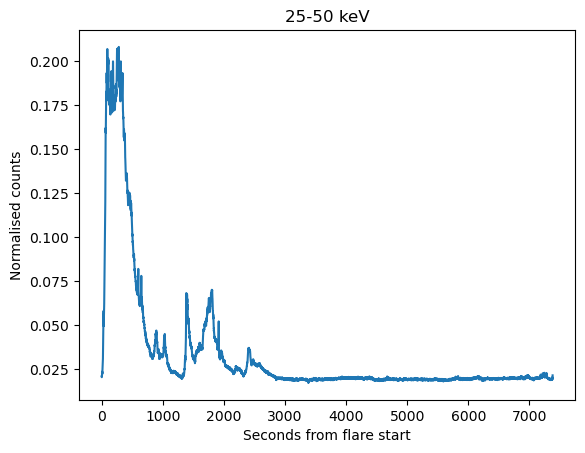

In [198]:
plt.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'])
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
#plt.legend()
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_7/100_top_counts_2550.png", bbox_inches='tight')

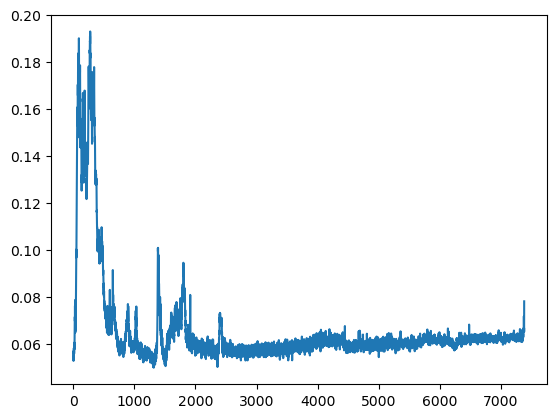

In [192]:
plt.plot(averaged_shape_flare_50100.index, averaged_shape_flare_50100['50.0 keV-100.0 keV'])

In [194]:
timeshifted_peaks_df_list = []
i=0
for df in normalised_df_list:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['25.0 keV-50.0 keV'] == np.max(df['25.0 keV-50.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    #timeshifted_df = timeshifted_df.truncate(-1200, 1200)
    timeshifted_peaks_df_list.append(timeshifted_df)
    i+=1

In [195]:
concat_band1_peaks = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_peaks_df_list), axis=1)
concat_band2_peaks = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_peaks_df_list), axis=1)
averaged_shape_flare_2550_peaks = pd.DataFrame(concat_band1_peaks.mean(axis=1), columns=['25.0 keV-50.0 keV'])
averaged_shape_flare_50100_peaks = pd.DataFrame(concat_band2_peaks.mean(axis=1), columns=['50.0 keV-100.0 keV'])

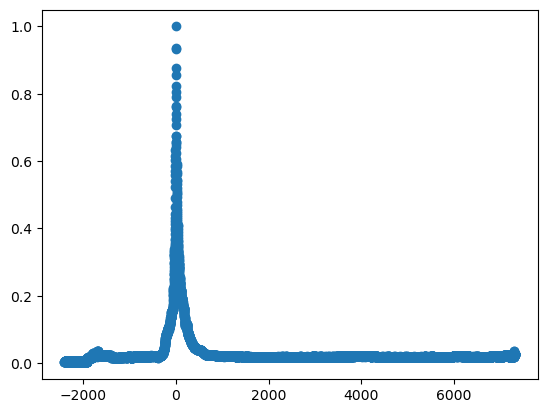

In [197]:
plt.scatter(averaged_shape_flare_2550_peaks.index, averaged_shape_flare_2550_peaks['25.0 keV-50.0 keV'])